In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
clean_df = pd.read_csv(
"C:/Users/Dell/OneDrive/Desktop/Retail-Customer-Intelligence/data/cleaned/clean_retail.csv"
)

In [3]:
clean_df["InvoiceDate"] = pd.to_datetime(
clean_df["InvoiceDate"]
)

In [4]:
#daily sales series
daily_sales = (
clean_df
.groupby(
clean_df["InvoiceDate"].dt.date
)
["TotalPrice"]
.sum()
)

daily_sales.head()

InvoiceDate
2010-12-01    46192.49
2010-12-02    47197.57
2010-12-03    23876.63
2010-12-05    31361.28
2010-12-06    31009.33
Name: TotalPrice, dtype: float64

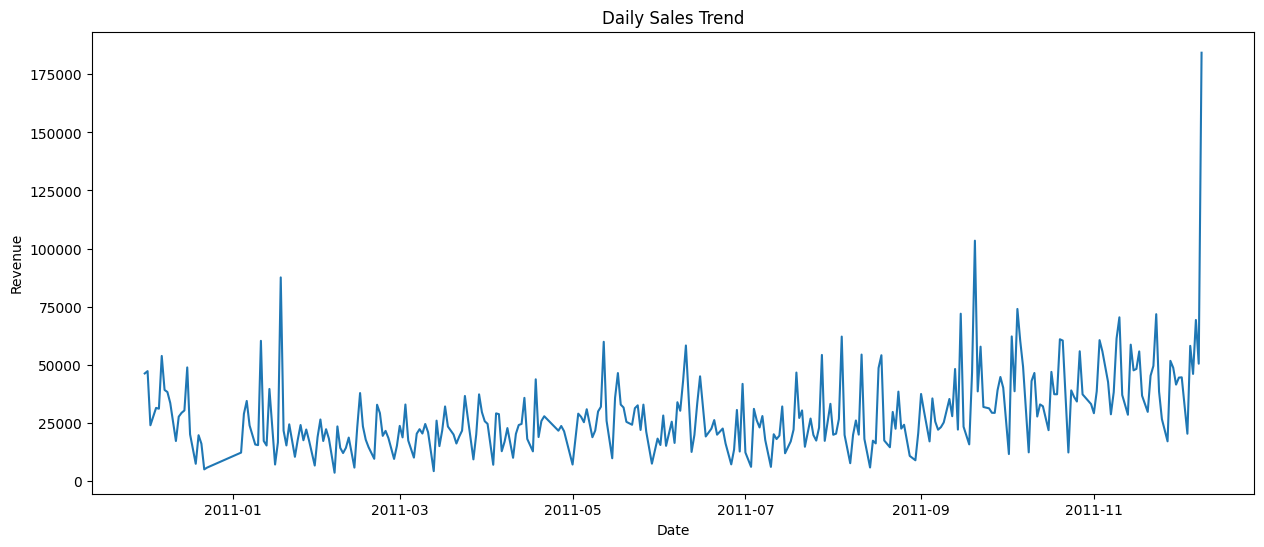

In [5]:
#visualize sales trend
plt.figure(figsize=(15,6))

plt.plot(
daily_sales.index,
daily_sales.values
)

plt.title(
"Daily Sales Trend"
)

plt.xlabel(
"Date"
)

plt.ylabel(
"Revenue"
)

plt.show()

In [6]:
#smooth with rolling average
rolling_sales = (
daily_sales
.rolling(7)
.mean()
)

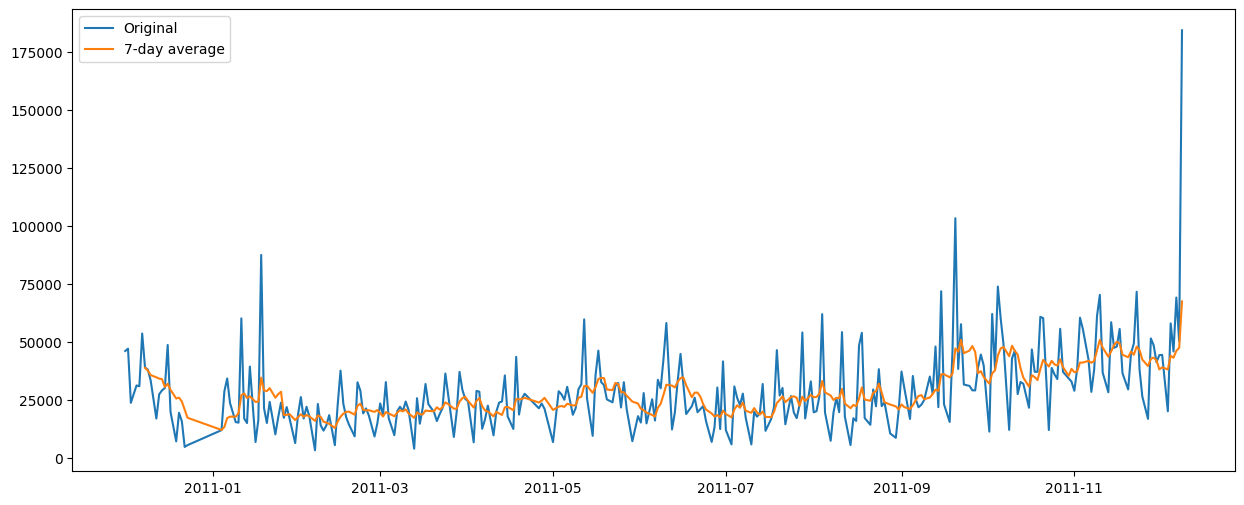

In [7]:
plt.figure(figsize=(15,6))

plt.plot(
daily_sales.index,
daily_sales.values,
label="Original"
)

plt.plot(
rolling_sales.index,
rolling_sales.values,
label="7-day average"
)

plt.legend()

plt.show()

In [8]:
#forecasting
!pip install prophet

In [9]:
from prophet import Prophet

In [10]:
forecast_df = daily_sales.reset_index()

forecast_df.columns = [
"ds",
"y"
]

forecast_df.head()

,ds,y
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


In [11]:
#train model
model = Prophet()

model.fit(
forecast_df
)

17:09:36 - cmdstanpy - INFO - Chain [1] start processing
17:09:37 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
#predict next 30 days
future = model.make_future_dataframe(
periods=30
)

forecast = model.predict(
future
)

In [13]:
forecast[
[
"ds",
"yhat",
"yhat_lower",
"yhat_upper"
]
].tail()

,ds,yhat,yhat_lower,yhat_upper
330,2012-01-04,56819.781345,39739.984104,75157.556851
331,2012-01-05,64274.138088,45840.548506,81342.625488
332,2012-01-06,56479.586924,37487.899643,73936.940963
333,2012-01-07,68594.077786,51574.279657,85754.528258
334,2012-01-08,43310.948543,26147.914453,61200.565200


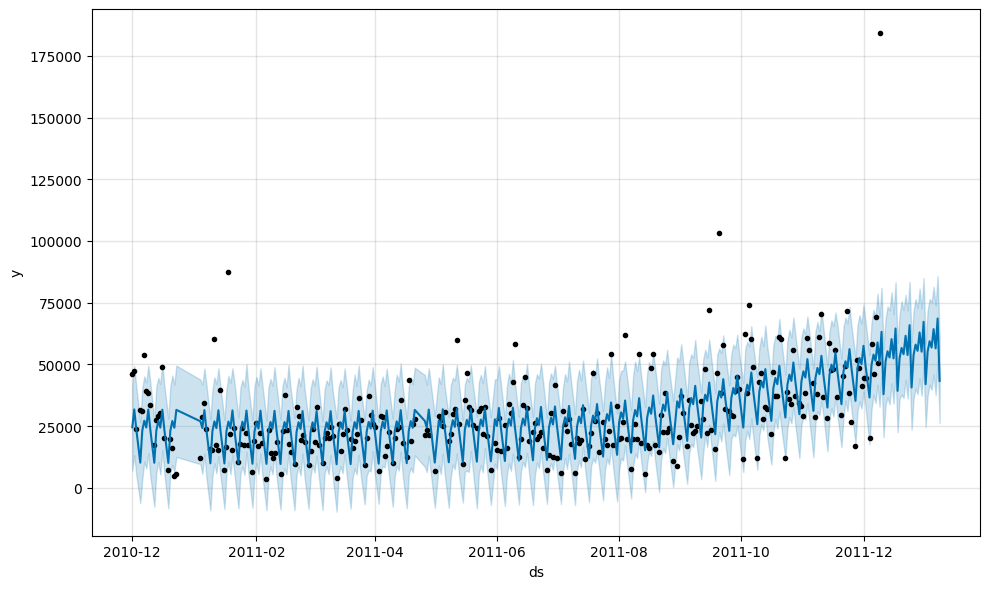

In [14]:
model.plot(
forecast
)

plt.show()

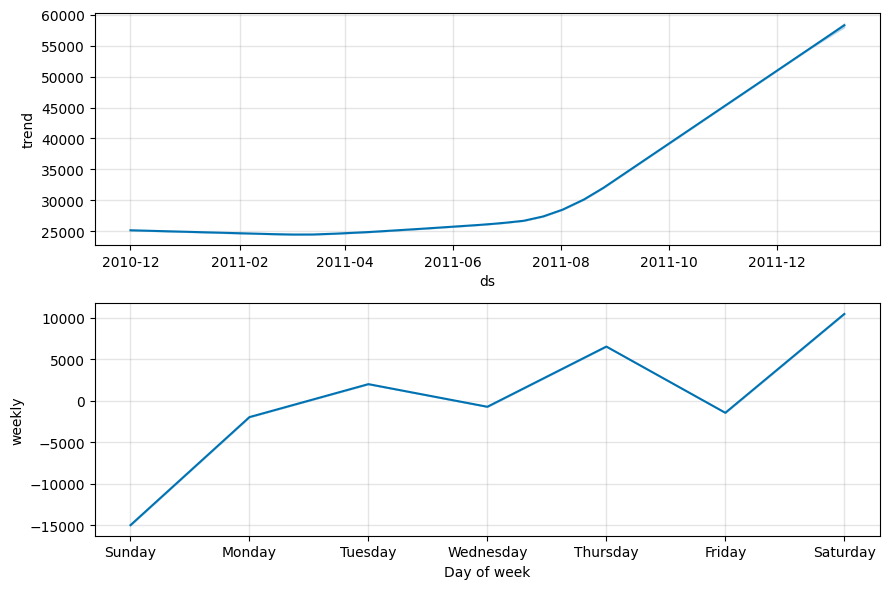

In [15]:
fig = model.plot_components(
forecast
)

plt.show()